# Magnus Carlsen Performance Analysis — Exploratory Data Analysis

Building on the cleaned dataset of Magnus Carlsen's Chess.com games, this notebook conducts a deep statistical exploration of his playing style and psychological resilience. It mathematically profiles his opening repertoire using standardized risk tiers and multi-dimensional area ratings, evaluates his move accuracy across varying time formats (Bullet, Blitz, and Rapid), and investigates "tilt" by tracking his performance and recovery immediately following unexpected losses.

In [1]:
import pandas as pd
import numpy as np
games=pd.read_csv("magnus_cleaned_games.csv")
chess_games=pd.read_csv("magnus_cleaned_chess_games.csv")

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.dates as mdates
import seaborn as sns

### Dataset sanity check, rules & time_class breakdown

In [3]:
pd.Series(games.columns)

0                          url
1                   time_class
2                 time_control
3                        rated
4                        rules
5                     end_time
6                      eco_url
7                      opening
8               white_username
9                 white_rating
10                white_result
11              black_username
12                black_rating
13                black_result
14                magnus_color
15               magnus_rating
16             opponent_rating
17               magnus_result
18              white_accuracy
19              black_accuracy
20             magnus_accuracy
21                        date
22                        year
23        magnus_result_simple
24                 prev_result
25              opening_simple
26           opponent_accuracy
27                   game_type
28    time_since_last_game_min
29              is_new_session
30                  session_id
31      game_number_in_session
32      

In [4]:
games.groupby('rules')['time_class'].value_counts().unstack()


time_class,blitz,bullet,rapid
rules,,,
chess,6540.0,2096.0,315.0
chess960,275.0,7.0,NaN


In [5]:
games[games['rules'] == 'chess960'].groupby('rules')['rated'].value_counts().unstack(fill_value=0)

rated,False,True
rules,,
chess960,6,276


---
## 1. Does he WIN more in Messy games or Clean games?

In [6]:
win_rates = chess_games[chess_games['game_type'].isin(['clean', 'messy'])].groupby('game_type').agg({
    'magnus_result_simple': lambda x: (x == 'win').mean()
}).round(3)

print("Magnus's win rate by game type:")
print(win_rates)
print(f"\nGame distribution:")
print(chess_games['game_type'].value_counts())

Magnus's win rate by game type:
           magnus_result_simple
game_type                      
clean                     0.120
messy                     0.622

Game distribution:
game_type
mixed    6918
messy    1548
clean     485
Name: count, dtype: int64


In [7]:
#Full breakdown of outcomes for Clean vs. Messy games
outcome_summary = (
    chess_games[chess_games['game_type'].isin(['clean', 'messy'])]
    .groupby('game_type')['magnus_result_simple']
    .value_counts(normalize=True)
    .unstack()
    .round(3)*100
)

print(outcome_summary)

magnus_result_simple  draw  loss   win
game_type                             
clean                 81.6   6.4  12.0
messy                 10.9  26.9  62.2


### Finding: Clean vs Messy Game Outcomes

Contrary to the simple hypothesis that "messy games favor Magnus," the data reveals a more 
nuanced pattern: clean games (both players ≥93.84% accuracy) overwhelmingly end in draws (81.6%), 
while messy games (both players ≤85.54% accuracy) are far more decisive, with draws dropping to 10.9%.

Within decisive outcomes specifically, Magnus's win:loss ratio is slightly better in messy games 
(2.3:1) than clean games (1.9:1) — suggesting he doesn't fear chaotic positions and may hold a 
slight edge there. However, the dominant effect in the data is that game "cleanliness" primarily 
predicts draw likelihood, not who wins.

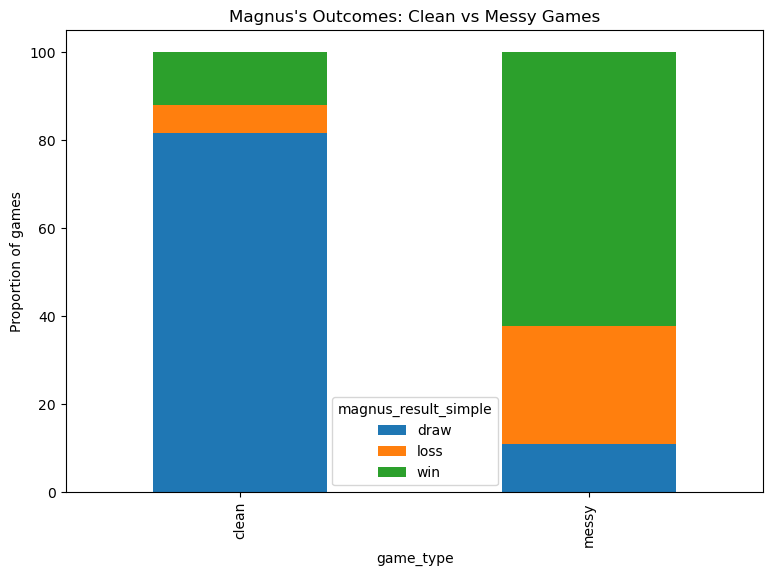

In [8]:
# plt.figure(figsize=(16,6))
outcome_summary.plot(kind='bar', stacked=True, figsize=(9,6))
plt.title("Magnus's Outcomes: Clean vs Messy Games")
plt.ylabel("Proportion of games")
plt.show()

---
## 2. Does he play worse right afrer a Loss? (chess)

In [9]:
# 1. Filter for games that are NOT the first game of a session
same_session_games = chess_games[chess_games['game_number_in_session'] > 1].copy()

# 2. Aggregated metrics grouped by previous game result
post_loss_summary = same_session_games.groupby('prev_result').agg(
    total_games=('magnus_accuracy', 'count'),
    avg_accuracy=('magnus_accuracy', 'mean'),
    median_accuracy=('magnus_accuracy', 'median'),
    win_rate=('magnus_result_simple', lambda x: (x == 'win').mean() * 100),
    loss_rate=('magnus_result_simple', lambda x: (x == 'loss').mean() * 100)
).round(2)

print("--- Performance Following Previous Game Result (Same Session) ---")
print(post_loss_summary)

--- Performance Following Previous Game Result (Same Session) ---
             total_games  avg_accuracy  median_accuracy  win_rate  loss_rate
prev_result                                                                 
draw                 996         89.51            90.47     63.15      20.18
loss                1458         88.46            89.44     67.22      20.78
win                 5612         89.21            90.24     71.29      16.95


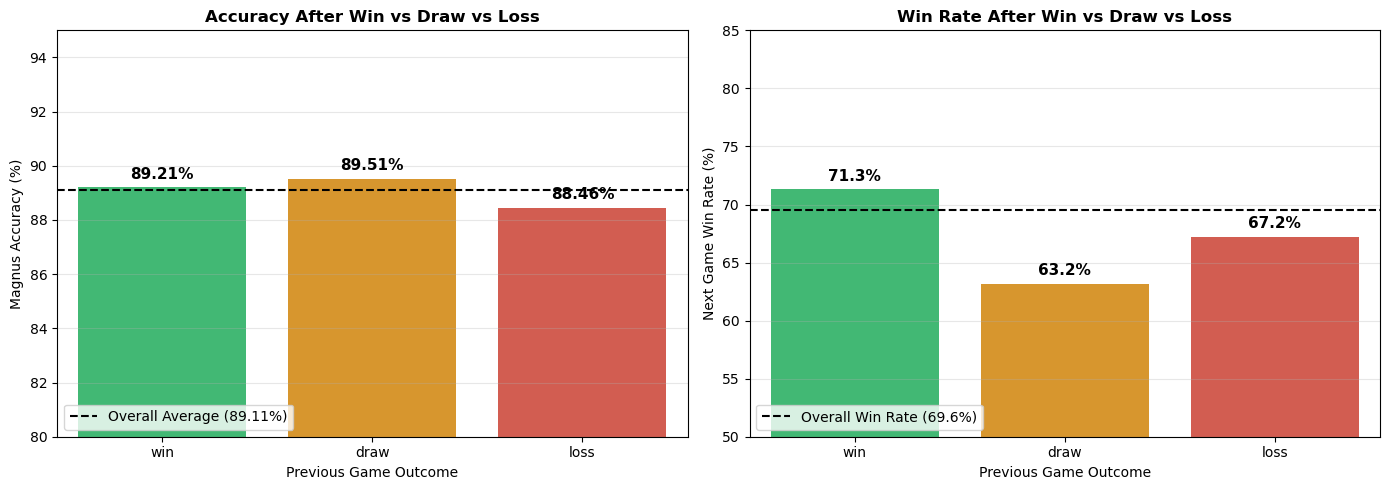

In [10]:
# 1. Calculate overall baselines across all in-session games
overall_avg_acc = same_session_games['magnus_accuracy'].mean()
overall_win_rate = (same_session_games['magnus_result_simple'] == 'win').mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Accuracy After Win vs Draw vs Loss ---
sns.barplot(
    data=same_session_games,
    x='prev_result',
    y='magnus_accuracy',
    hue='prev_result',          # <-- Added to fix the warning
    legend=False,               # <-- Added to prevent duplicate legends
    order=['win', 'draw', 'loss'],
    palette=['#2ecc71', '#f39c12', '#e74c3c'],
    errorbar=None,
    ax=axes[0]
)

# Overlay overall average accuracy line
axes[0].axhline(
    overall_avg_acc, 
    color='black', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Overall Average ({overall_avg_acc:.2f}%)'
)

for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(
        f'{height:.2f}%',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 4), textcoords='offset points'
    )

axes[0].set_title('Accuracy After Win vs Draw vs Loss', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Magnus Accuracy (%)')
axes[0].set_xlabel('Previous Game Outcome')
axes[0].set_ylim(80, 95)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].legend(loc='lower left')

# --- Plot 2: Win Rate After Win vs Draw vs Loss ---
win_rates = same_session_games.groupby('prev_result')['magnus_result_simple'].apply(lambda x: (x == 'win').mean() * 100).reindex(['win', 'draw', 'loss'])

sns.barplot(
    x=win_rates.index,
    y=win_rates.values,
    hue=win_rates.index,        # <-- Added to fix the warning
    legend=False,               # <-- Added to prevent duplicate legends
    palette=['#2ecc71', '#f39c12', '#e74c3c'],
    ax=axes[1]
)

# Overlay overall win rate baseline line
axes[1].axhline(
    overall_win_rate, 
    color='black', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Overall Win Rate ({overall_win_rate:.1f}%)'
)

for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 4), textcoords='offset points'
    )

axes[1].set_title('Win Rate After Win vs Draw vs Loss', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Next Game Win Rate (%)')
axes[1].set_xlabel('Previous Game Outcome')
axes[1].set_ylim(50, 85)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

---
## 3. Does an upset loss trigger stronger tilt than a regular loss? (all)

In [11]:
# 1. Shift is_upset within each session 
# Added .astype('boolean') before fillna() to prevent the silent downcasting warning
prev_is_upset = (
    games.groupby('session_id')['is_upset']
    .shift(1)
    .astype('boolean')
    .fillna(False)
    .astype(bool)
)

# 2. Vectorized classification for prior game context
conditions = [
    (games['prev_result'] == 'loss') & prev_is_upset,
    (games['prev_result'] == 'loss') & (~prev_is_upset),
    games['prev_result'] == 'draw',
    games['prev_result'] == 'win'
]
choices = ['After Upset Loss', 'After Normal Loss', 'After Draw', 'After Win']

# default=None creates an Object array cleanly compatible with None/NaN filtering
prev_context = pd.Series(
    np.select(conditions, choices, default=None), 
    index=games.index
)

# Filter out first games of a session
valid_mask = prev_context.notna()
valid_context = prev_context[valid_mask]
valid_games = games[valid_mask]

# 3. Performance summary: Accuracy metrics + Outcome breakdown
acc_stats = (
    valid_games.groupby(valid_context)['magnus_accuracy']
    .agg(total_games='count', avg_accuracy='mean', median_accuracy='median')
    .round(2)
)

outcomes = (
    pd.crosstab(
        valid_context, valid_games['magnus_result_simple'], normalize='index'
    ) * 100
).round(2)

# Final combined view
tilt_analysis = acc_stats.join(outcomes)
print(tilt_analysis)

                   total_games  avg_accuracy  median_accuracy   draw   loss  \
After Draw                1161         89.73            90.65  17.48  19.04   
After Normal Loss         1460         88.49            89.50  12.33  20.41   
After Upset Loss           151         88.33            89.72   8.61  16.56   
After Win                 6461         89.20            90.27  11.84  16.61   

                     win  
After Draw         63.48  
After Normal Loss  67.26  
After Upset Loss   74.83  
After Win          71.55  


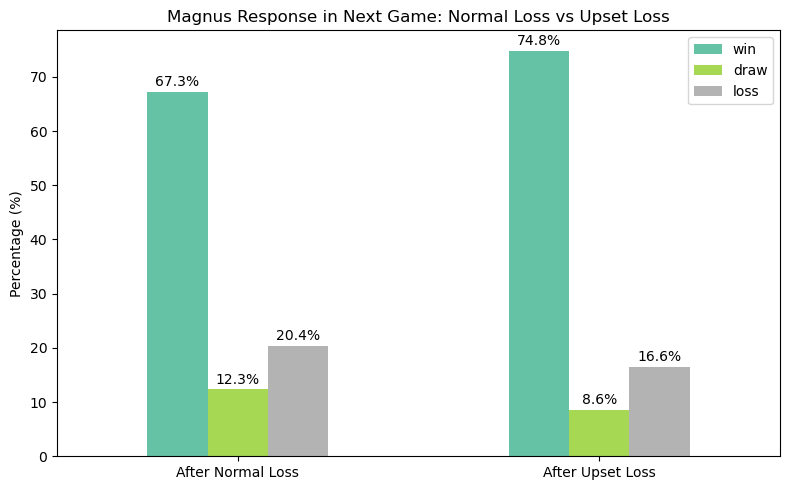

In [12]:
# Filter down to just the loss comparison
loss_comp = tilt_analysis.loc[['After Normal Loss', 'After Upset Loss'], ['win', 'draw', 'loss']]

ax = loss_comp.plot(kind='bar', figsize=(8, 5), rot=0, colormap='Set2')
plt.title('Magnus Response in Next Game: Normal Loss vs Upset Loss')
plt.ylabel('Percentage (%)')
plt.xlabel('')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)

plt.tight_layout()
plt.show()

### The 74.8% win rate after an upset loss isn't purely a psychological surge—it's mostly driven by data distribution and matchmaking logic. With only 151 upset follow-up games compared to 1,460 normal ones, the smaller sample size naturally holds higher variance and exaggerates the percentage. Additionally, online tournament pairing systems automatically match players against lower-rated opponents immediately after a loss, making a win in the next game much more likely.

---
## 4. Does he get tired during sessions? (all)

Average Session Length: 10.1 games
90th Percentile (Q90) Session Length: 23 games


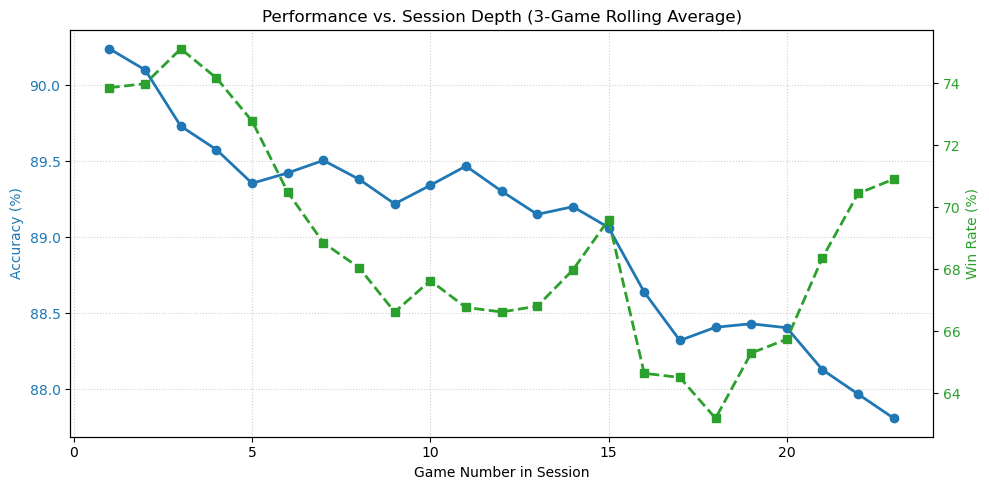

In [13]:
# 1. Calculate session length thresholds and print summary
session_lengths = games.groupby('session_id')['game_number_in_session'].max()
avg_length = session_lengths.mean()
p90_length = session_lengths.quantile(0.90)

print(f'Average Session Length: {avg_length:.1f} games')
print(f'90th Percentile (Q90) Session Length: {p90_length:.0f} games')

# 2. Group metrics by game position in session
session_progress = games.groupby('game_number_in_session').agg(
    total_games=('magnus_accuracy', 'count'),
    avg_accuracy=('magnus_accuracy', 'mean'),
    win_rate=('magnus_result_simple', lambda x: (x == 'win').mean() * 100),
)

# 3. Filter up to the 90th percentile limit
valid_progress = session_progress[session_progress.index <= p90_length].copy()

# 4. Apply a 3-game centered rolling average to smooth out noise
smooth_progress = valid_progress[['avg_accuracy', 'win_rate']].rolling(
    window=3, min_periods=1, center=True
).mean()

# 5. Plot smoothed trends across session depth
fig, ax1 = plt.subplots(figsize=(10, 5))

# Smoothed Accuracy Trend (Left Y-Axis)
ax1.plot(
    smooth_progress.index,
    smooth_progress['avg_accuracy'],
    color='tab:blue',
    marker='o',
    linewidth=2,
    label='Avg Accuracy (3-Game Rolling)',
)
ax1.set_xlabel('Game Number in Session')
ax1.set_ylabel('Accuracy (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Smoothed Win Rate Trend (Right Y-Axis)
ax2 = ax1.twinx()
ax2.plot(
    smooth_progress.index,
    smooth_progress['win_rate'],
    color='tab:green',
    marker='s',
    linestyle='--',
    linewidth=2,
    label='Win Rate (3-Game Rolling)',
)
ax2.set_ylabel('Win Rate (%)', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

plt.title('Performance vs. Session Depth (3-Game Rolling Average)')
ax1.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### "Magnus exhibits clear cognitive fatigue over extended sessions, evidenced by a steady linear drop in move accuracy from ~90.3% to ~87.8%. While his win rate temporarily recovers late in sessions (games 18+), this is driven by matchmaking adjustments—where lower ratings paired him against easier or equally fatigued opponents—rather than a recovery in play quality."

---
## 5. What are Magnus's most played openings, and what's his win rate in each? (chess)

In [14]:
most_played=chess_games['opening_simple'].value_counts().head(6)
print(most_played)
top6=list(most_played.index)
top6

opening_simple
Sicilian Defense    1344
Kings Indian         616
English Opening      576
Queens Gambit        510
Queens Pawn          459
French Defense       448
Name: count, dtype: int64


['Sicilian Defense',
 'Kings Indian',
 'English Opening',
 'Queens Gambit',
 'Queens Pawn',
 'French Defense']

In [15]:
chess_games['magnus_result_simple'].value_counts()

magnus_result_simple
win     6253
loss    1560
draw    1138
Name: count, dtype: int64

In [16]:
win_rates=list()

for i in range(len(top6)):
    win_rate=(round((chess_games[chess_games['opening_simple']==top6[i]]['magnus_result_simple']=='win').mean()*100,3))
    win_rates.append(float(win_rate))

win_rates

[70.089, 73.539, 71.875, 68.039, 70.588, 68.973]

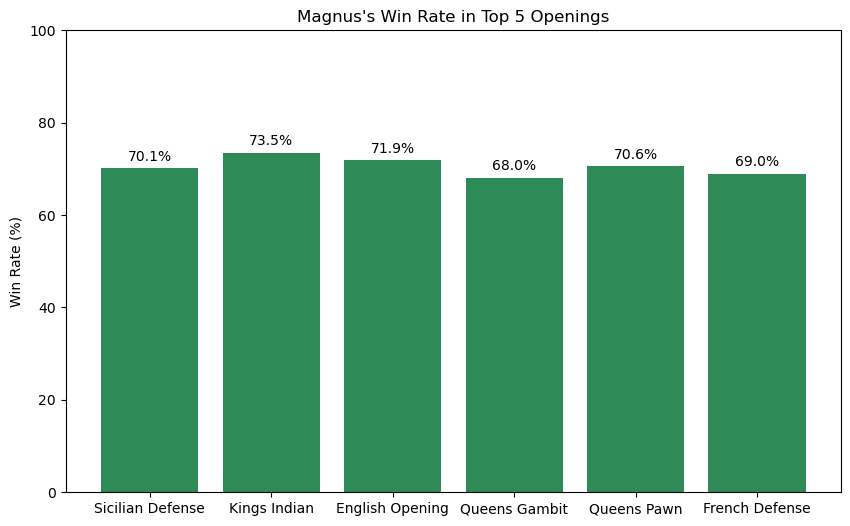

In [17]:
plt.figure(figsize=(10,6))
bars = plt.bar(top6, win_rates, color='seagreen')
plt.title("Magnus's Win Rate in Top 5 Openings")
plt.ylabel("Win Rate (%)")
plt.ylim(0,100)

for bar, rate in zip(bars, win_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{rate:.1f}%", ha='center', va='bottom')

plt.show()


---
## 6. Which opening are "Safe" vs "Risky"? (chess)

In [18]:
import scipy.stats as stats

# 1. Filter for openings with N >= 200 games
MIN_GAMES = 200
counts = chess_games['opening_simple'].value_counts()
robust_openings = counts[counts >= MIN_GAMES].index

robust_games = chess_games[chess_games['opening_simple'].isin(robust_openings)]

# 2. Aggregate metrics
opening_stats = robust_games.groupby('opening_simple').agg(
    total_games=('magnus_accuracy', 'count'),
    avg_accuracy=('magnus_accuracy', 'mean'),
    win_rate=('magnus_result_simple', lambda x: (x == 'win').mean() * 100),
    loss_rate=('magnus_result_simple', lambda x: (x == 'loss').mean() * 100),
)

# 3. Calculate mean, std dev, and z-scores
mean_loss = opening_stats['loss_rate'].mean()
std_loss = opening_stats['loss_rate'].std()
opening_stats['loss_zscore'] = (
    opening_stats['loss_rate'] - mean_loss
) / std_loss


# 4. Classify risk using 0.5 sigma buffer
def classify_risk(z):
    if z < -0.5:
        return '1. Safe'
    elif z > 0.5:
        return '3. Risky'
    else:
        return '2. Neutral / Baseline'


opening_stats['risk_category'] = opening_stats['loss_zscore'].apply(
    classify_risk
)

# 5. Print results
print(
    f'Sample Size: {len(opening_stats)} Openings | Mean Loss:'
    f' {mean_loss:.2f}% | Std Dev: {std_loss:.2f}%\n'
)
sorted_df = opening_stats.sort_values(by='loss_rate')
print(
    sorted_df[
        [
            'total_games',
            'avg_accuracy',
            'win_rate',
            'loss_rate',
            'loss_zscore',
            'risk_category',
        ]
    ]
)

Sample Size: 12 Openings | Mean Loss: 17.25% | Std Dev: 1.85%

                  total_games  avg_accuracy   win_rate  loss_rate  \
opening_simple                                                      
Reti Opening              273     89.520513  73.260073  13.553114   
Kings Indian              616     89.891347  73.538961  14.935065   
Indian Game               372     89.665806  74.462366  15.322581   
English Opening           576     89.416424  71.875000  16.319444   
Sicilian Defense         1344     89.500789  70.089286  17.261905   
French Defense            448     89.440201  68.973214  17.410714   
Queens Gambit             510     90.750784  68.039216  17.843137   
Pirc Defense              218     89.172156  65.596330  18.348624   
Queens Pawn               459     88.501503  70.588235  18.736383   
Ruy Lopez                 399     91.238872  61.152882  19.047619   
Caro Kann                 387     88.875659  70.542636  19.121447   
Modern Defense            350     87.690

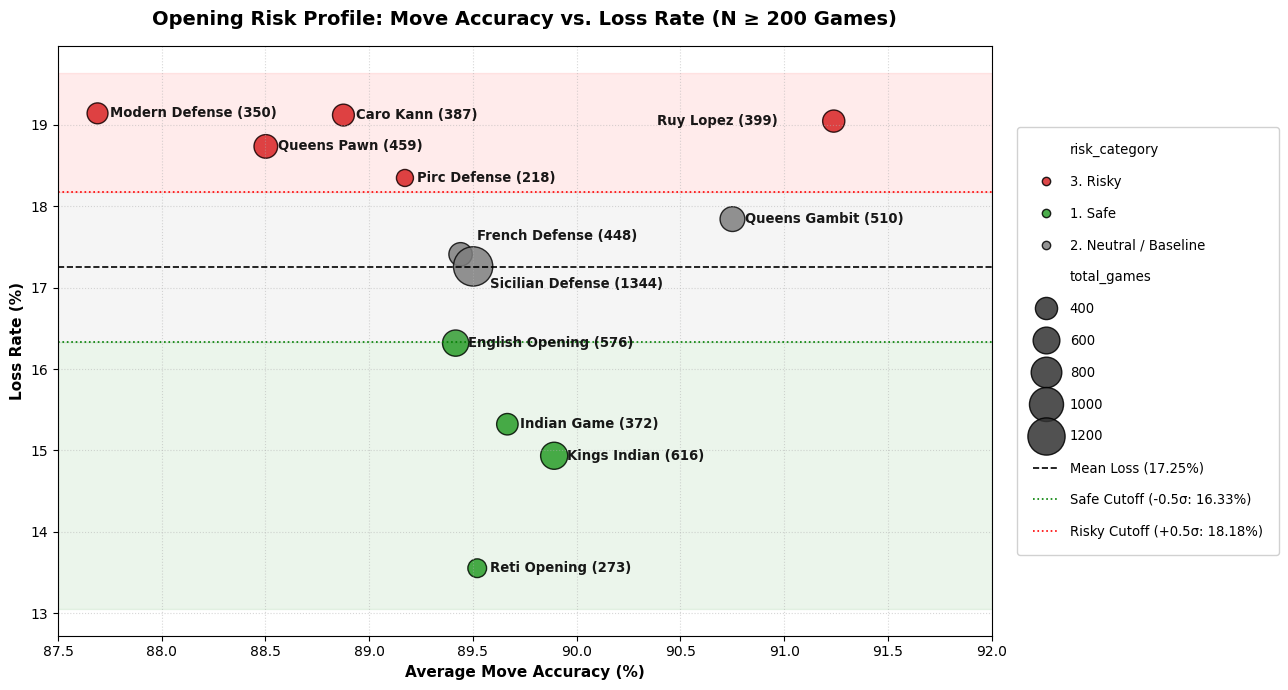

In [19]:
plt.figure(figsize=(13, 7))

# Palette for the three statistical tiers
palette = {
    '1. Safe': '#2ca02c',
    '2. Neutral / Baseline': '#7f7f7f',
    '3. Risky': '#d62728',
}

# Scatter Plot
scatter = sns.scatterplot(
    data=opening_stats,
    x='avg_accuracy',
    y='loss_rate',
    hue='risk_category',
    palette=palette,
    size='total_games',
    sizes=(150, 800),
    alpha=0.85,
    edgecolor='black',
    linewidth=1,
)

# Offsets to prevent label overlaps (French vs Sicilian) and edge clipping (Ruy Lopez)
text_offsets = {
    'Sicilian Defense': (0.08, -0.22),
    'French Defense': (0.08, 0.22),
    'Ruy Lopez': (-0.85, 0.0),  # Shifts text left of marker
}

for opening, row in opening_stats.iterrows():
    x_off, y_off = text_offsets.get(opening, (0.06, 0.0))
    plt.text(
        row['avg_accuracy'] + x_off,
        row['loss_rate'] + y_off,
        f"{opening} ({row['total_games']})",
        fontsize=9.5,
        weight='bold',
        va='center',
        alpha=0.9,
    )

# Statistical Threshold Lines
lower_bound = mean_loss - 0.5 * std_loss
upper_bound = mean_loss + 0.5 * std_loss

plt.axhline(
    mean_loss,
    color='black',
    linestyle='--',
    linewidth=1.2,
    label=f'Mean Loss ({mean_loss:.2f}%)',
)
plt.axhline(
    lower_bound,
    color='green',
    linestyle=':',
    linewidth=1.2,
    label=f'Safe Cutoff (-0.5σ: {lower_bound:.2f}%)',
)
plt.axhline(
    upper_bound,
    color='red',
    linestyle=':',
    linewidth=1.2,
    label=f'Risky Cutoff (+0.5σ: {upper_bound:.2f}%)',
)

# Background Regions
plt.axhspan(
    opening_stats['loss_rate'].min() - 0.5,
    lower_bound,
    color='green',
    alpha=0.08,
)
plt.axhspan(lower_bound, upper_bound, color='gray', alpha=0.08)
plt.axhspan(
    upper_bound,
    opening_stats['loss_rate'].max() + 0.5,
    color='red',
    alpha=0.08,
)

# Extend x-limits so labels aren't squashed against plot borders
plt.xlim(87.5, 92.0)

# De-suffocated & centered legend box
plt.legend(
    bbox_to_anchor=(1.02, 0.5),  # Centered vertically on right side
    loc='center left',
    frameon=True,
    facecolor='white',
    framealpha=0.9,
    fontsize=9.5,
    labelspacing=1.35,  # Spreads out vertical distance between items
    borderpad=1.2,  # Adds internal box padding
    handletextpad=0.8,  # Space between marker/line and text label
)

plt.title(
    'Opening Risk Profile: Move Accuracy vs. Loss Rate (N ≥ 200 Games)',
    fontsize=14,
    pad=15,
    weight='bold',
)
plt.xlabel('Average Move Accuracy (%)', fontsize=11, weight='bold')
plt.ylabel('Loss Rate (%)', fontsize=11, weight='bold')

plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


### To eliminate high-variance noise from low game counts, openings were filtered for a sample size of $N \ge 200$ games. Risk was categorized using a $0.5\sigma$ standard deviation buffer relative to the population mean loss rate ($\mu = 17.25\%, \sigma = 1.85\%$):
> * **Safe Tier ($z < -0.5$):** *Reti Opening*, *King's Indian*, *Indian Game*, and *English Opening*. Characterized by strong loss suppression ($13.5\% - 16.3\%$) and win rates exceeding $71.8\%$.
> * **Neutral Baseline ($-0.5 \le z \le +0.5$):** *Sicilian Defense*, *French Defense*, and *Queen's Gambit*. Forms his primary high-volume core repertoire centered exactly at his performance mean.
> * **Risky Tier ($z > +0.5$):** *Pirc Defense*, *Queen's Pawn*, *Ruy Lopez*, *Caro-Kann*, and *Modern Defense*. Driven either by sharp theoretical prep where small mistakes lose games despite $91\%+$ accuracy (*Ruy Lopez*), or chaotic structures where accuracy drops below $88\%$ (*Modern Defense*).
> 
>

---
## 7. Does his accuracy vary by Time Format: Bullet - Blitz - Rapid (chess)

In [20]:
print("--- Game Count per Time Format ---")
print(chess_games['time_class'].value_counts())

--- Game Count per Time Format ---
time_class
blitz     6540
bullet    2096
rapid      315
Name: count, dtype: int64


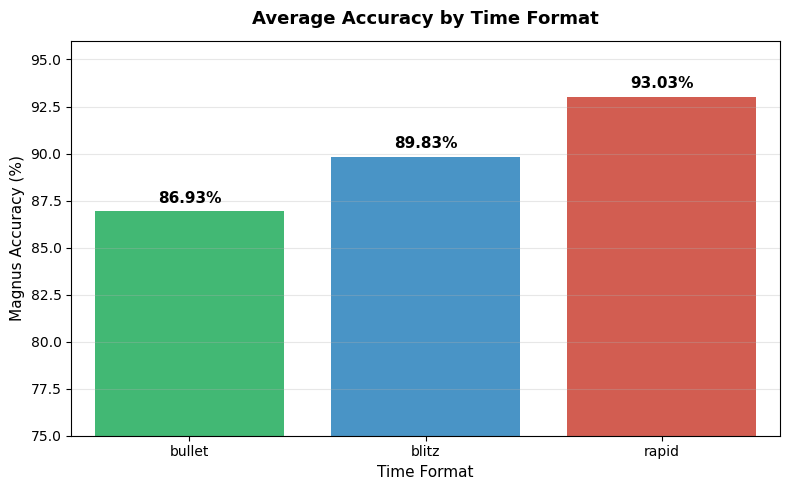

In [21]:
plt.figure(figsize=(8, 5))

# Plot bars without error bars
ax = sns.barplot(
    data=chess_games, 
    x='time_class', 
    y='magnus_accuracy', 
    hue='time_class',          # <-- Added to fix the warning
    legend=False,              # <-- Added to prevent a duplicate legend
    order=['bullet', 'blitz', 'rapid'],
    palette=['#e74c3c', '#3498db', '#2ecc71'],
    errorbar=None
)

# Add exact average percentage values on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.2f}%',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        xytext=(0, 4), textcoords='offset points'
    )

plt.title('Average Accuracy by Time Format', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Magnus Accuracy (%)', fontsize=11)
plt.xlabel('Time Format', fontsize=11)
plt.ylim(75, 96)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

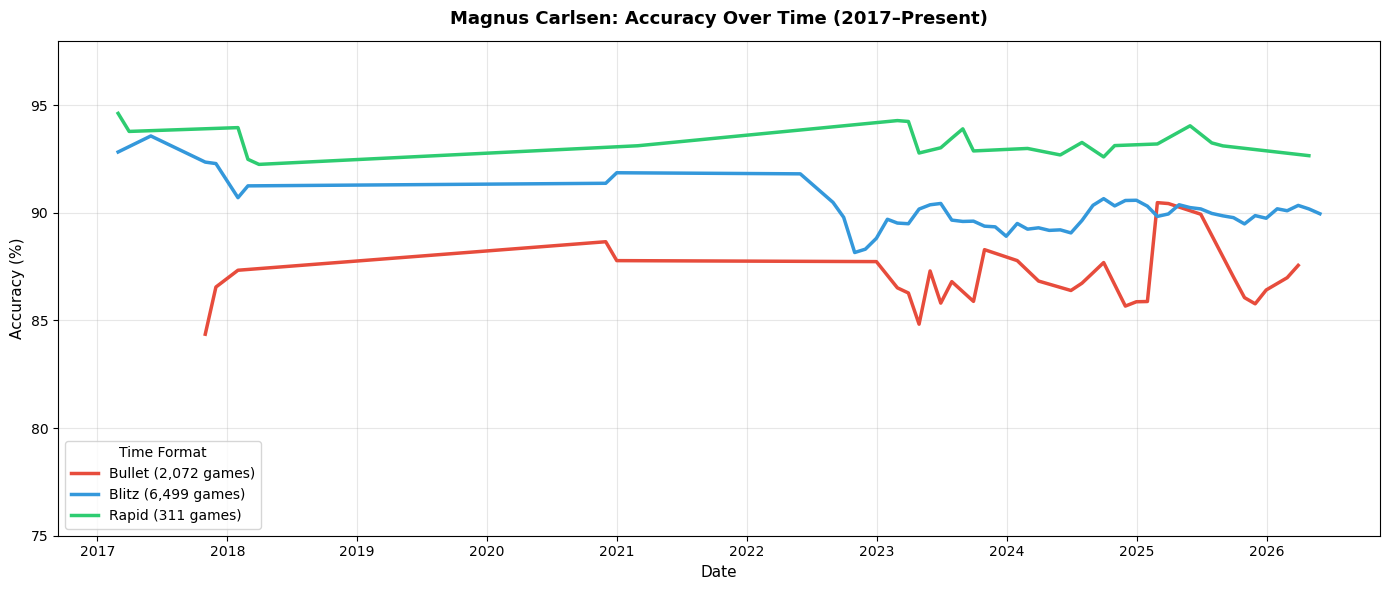

In [22]:
chess_games['date'] = pd.to_datetime(chess_games['date'])
# 1. Filter dataset for 2017 onwards
df_2017 = chess_games[pd.to_datetime(chess_games['date']) >= '2017-01-01'].sort_values('date').copy()

plt.figure(figsize=(14, 6))

colors = {
    'bullet': '#e74c3c',
    'blitz': '#3498db',
    'rapid': '#2ecc71'
}

# 2. Plot 3-month rolling average for each format
for tc in ['bullet', 'blitz', 'rapid']:
    subset = df_2017[df_2017['time_class'] == tc].copy()
    
    if not subset.empty:
        monthly_acc = (
            subset.set_index('date')['magnus_accuracy']
            .resample('ME')
            .mean()
            .dropna()
        )
        
        smoothed = monthly_acc.rolling(window=3, min_periods=1).mean()
        
        plt.plot(
            smoothed.index, 
            smoothed.values, 
            label=f"{tc.capitalize()} ({len(subset):,} games)", 
            color=colors[tc], 
            linewidth=2.5
        )

plt.title("Magnus Carlsen: Accuracy Over Time (2017–Present)", fontsize=13, fontweight='bold', pad=12)
plt.ylabel("Accuracy (%)", fontsize=11)
plt.xlabel("Date", fontsize=11)
plt.ylim(75, 98)
plt.grid(True, alpha=0.3)
plt.legend(title="Time Format", loc="lower left")

# Format X-axis ticks by year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

---
## 8. Has his Win rate/Performance changed over the years (2014 - 2026)? (for each(all three))

In [23]:
def plot_monthly_trend(df, title_text, line_color='#1f77b4', start_date='2022-01-01'):
    """
    Plots monthly win rate and 6-month rolling average for a given chess DataFrame from start_date onwards.
    """
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    
    # 1. Filter for data from 2022 onwards
    if start_date:
        df = df[df['date'] >= start_date]
    
    # 2. Group by month and calculate win rate (%)
    df['year_month'] = df['date'].dt.to_period('M')
    
    monthly = (
        df.groupby('year_month')['magnus_result_simple']
        .apply(lambda x: (x == 'win').mean() * 100)
        .to_frame(name='win_rate')
    )
    
    # 3. Convert PeriodIndex back to Datetime for mdates
    monthly.index = monthly.index.to_timestamp()
    
    # 4. Calculate 6-month rolling average
    monthly['rolling_6m'] = monthly['win_rate'].rolling(window=6, min_periods=1).mean()
    
    # 5. Generate Plot
    plt.figure(figsize=(12, 5))
    
    # Raw monthly win rate points in background
    plt.plot(
        monthly.index, monthly['win_rate'], 
        alpha=0.35, color='gray', linestyle='--', marker='o', label='Monthly Win Rate'
    )
    
    # Smoothed 6-month trendline
    plt.plot(
        monthly.index, monthly['rolling_6m'], 
        linewidth=2.5, color=line_color, label='6-Month Rolling Average'
    )
    
    plt.title(f"{title_text} (2022–Present | Total Games: {len(df):,})", fontsize=13, fontweight='bold', pad=12)
    plt.ylabel("Win Rate (%)", fontsize=11)
    plt.xlabel("Year", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='lower left')
    
    # Format x-axis for 2022 onwards
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    plt.tight_layout()
    plt.show()

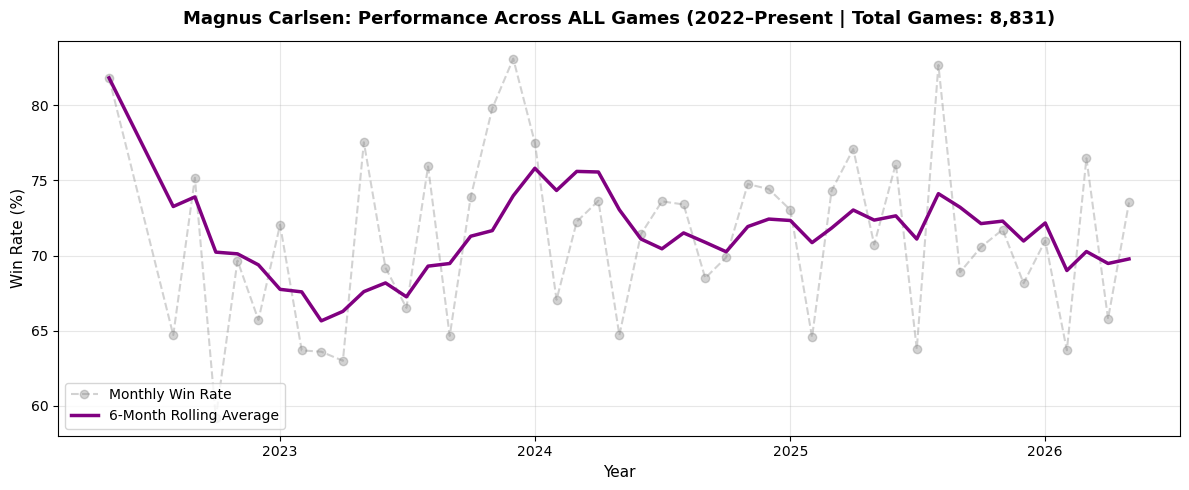

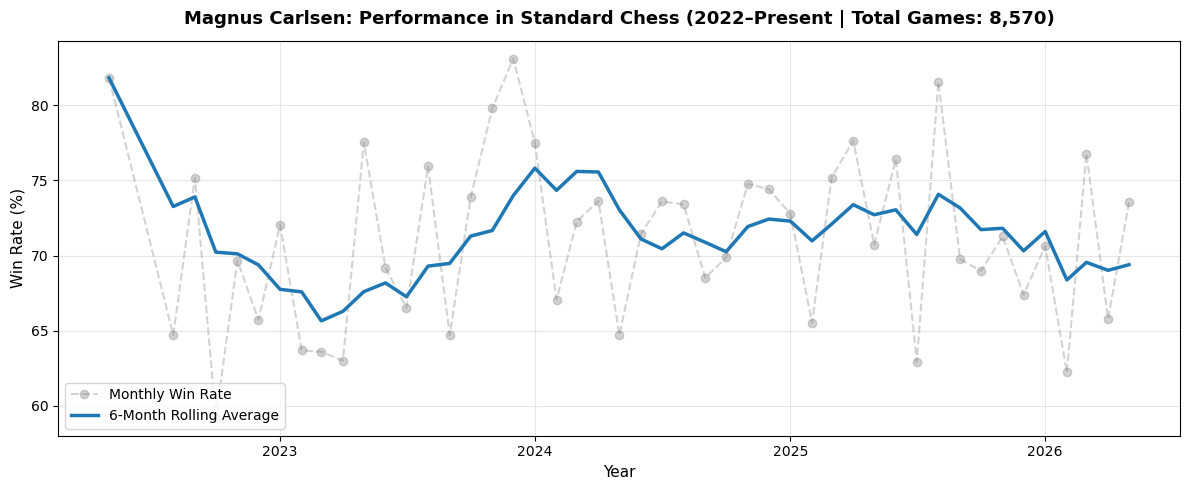

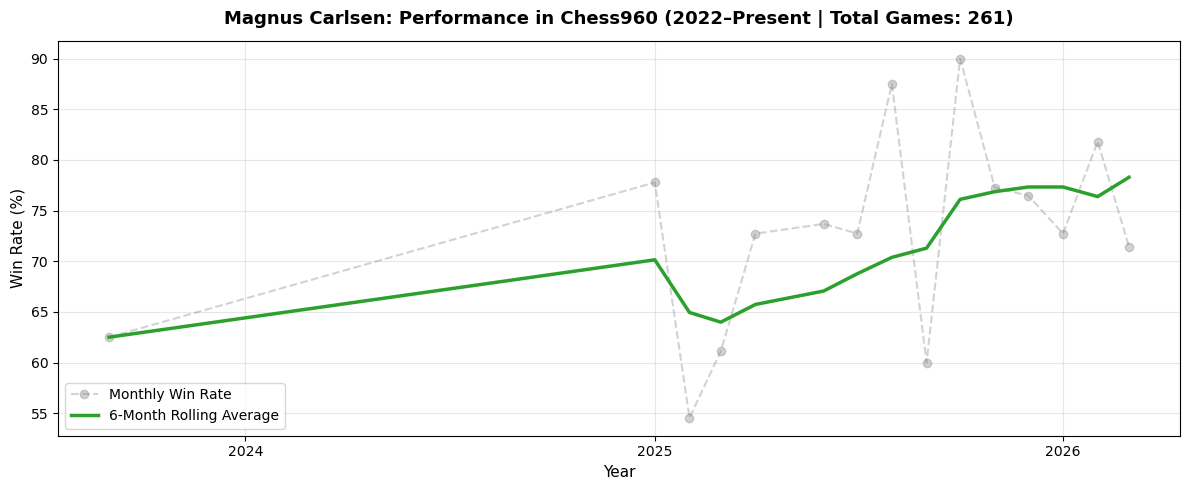

In [24]:
# 1. Create Chess960 subset (adjust 'rules' value if your dataset uses 'chess_960' or similar)
chess960_games = games[games['rules'] == 'chess960'].copy()


# --- Plot 1: Entire Dataset (All Rules) ---
plot_monthly_trend(games, "Magnus Carlsen: Performance Across ALL Games", line_color='purple')

# --- Plot 2: Standard Chess Only ---
plot_monthly_trend(chess_games, "Magnus Carlsen: Performance in Standard Chess", line_color='#1f77b4')

# --- Plot 3: Chess960 Only ---
plot_monthly_trend(chess960_games, "Magnus Carlsen: Performance in Chess960", line_color='#2ca02c')

---
## 9. Does high accuracy always correlate with winning, or does he sometimes win despite lower accuracy? (resilience) (chess & chess960)

Restricted to chess/chess960 comparison; overall and chess_games results were nearly identical, so including 'overall' separately would be redundant.

In [25]:
q75_chess = chess_games['magnus_accuracy'].quantile(0.75)

is_high_acc_chess = chess_games['magnus_accuracy'] >= q75_chess

chess960 = games[games['rules'] == 'chess960']
q75_960 = chess960['magnus_accuracy'].quantile(0.75)

is_high_acc_960 = chess960['magnus_accuracy'] >= q75_960

# Standard Chess Breakdown
print("--- Standard Chess ---")
print(pd.crosstab(is_high_acc_chess.rename('high_accuracy'), chess_games['magnus_result_simple'], normalize='index').round(4) * 100)

# Chess960 Breakdown
print("\n--- Chess960 ---")
print(pd.crosstab(is_high_acc_960.rename('high_accuracy'), chess960['magnus_result_simple'], normalize='index').round(4) * 100)

--- Standard Chess ---
magnus_result_simple   draw   loss    win
high_accuracy                            
False                 10.77  22.69  66.54
True                  18.54   1.65  79.81

--- Chess960 ---
magnus_result_simple   draw   loss    win
high_accuracy                            
False                  7.14  27.14  65.71
True                  11.11   0.00  88.89


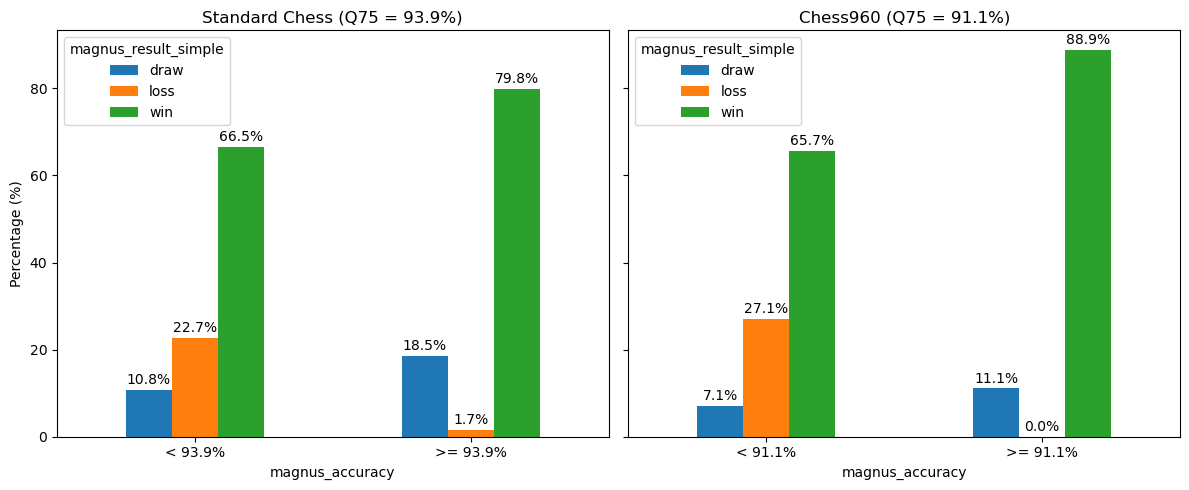

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Standard Chess
(pd.crosstab(is_high_acc_chess, chess_games['magnus_result_simple'], normalize='index') * 100)\
    .rename(index={False: f'< {q75_chess:.1f}%', True: f'>= {q75_chess:.1f}%'})\
    .plot(kind='bar', ax=ax1, title=f'Standard Chess (Q75 = {q75_chess:.1f}%)', rot=0)

# Chess960
(pd.crosstab(is_high_acc_960, chess960['magnus_result_simple'], normalize='index') * 100)\
    .rename(index={False: f'< {q75_960:.1f}%', True: f'>= {q75_960:.1f}%'})\
    .plot(kind='bar', ax=ax2, title=f'Chess960 (Q75 = {q75_960:.1f}%)', rot=0)

# Add exact percentage labels on top of every bar
for ax in (ax1, ax2):
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=2)

ax1.set_ylabel('Percentage (%)')
plt.tight_layout()
plt.show()

---
## 10. Top five Openings compared accross win rate, accuracy, and frequency. (normalised to same scale) (chess)

In [27]:
import math

# 1. Extract Top 6 Openings by game count
top6_openings = chess_games['opening_simple'].value_counts().head(6).index
top6_games = chess_games[chess_games['opening_simple'].isin(top6_openings)]

# 2. Aggregate raw metrics per opening
metrics = (
    top6_games.groupby('opening_simple')
    .agg(
        total_games=('magnus_accuracy', 'count'),
        avg_accuracy=('magnus_accuracy', 'mean'),
        std_accuracy=('magnus_accuracy', 'std'),
        win_rate=(
            'magnus_result_simple',
            lambda x: (x == 'win').mean() * 100.0,
        ),
        loss_rate=(
            'magnus_result_simple',
            lambda x: (x == 'loss').mean() * 100.0,
        ),
    )
    .reindex(top6_openings)
)  # Retain top-to-bottom rank order

# 3. Construct 5 positive-oriented feature dimensions
metrics['Win Rate (%)'] = metrics['win_rate']
metrics['Safety Rate (%)'] = 100.0 - metrics['loss_rate']
metrics['Accuracy (%)'] = metrics['avg_accuracy']
metrics['Consistency (%)'] = 100.0 - metrics['std_accuracy'].fillna(0)
metrics['Frequency (%)'] = (
    metrics['total_games'] / metrics['total_games'].sum()
) * 100.0

feature_cols = [
    'Win Rate (%)',
    'Safety Rate (%)',
    'Accuracy (%)',
    'Consistency (%)',
    'Frequency (%)',
]

# 4. Uniform Min-Max Normalization with [20, 80] padding bounds
norm_df = pd.DataFrame(index=metrics.index)
for col in feature_cols:
    col_min = metrics[col].min()
    col_max = metrics[col].max()
    if col_max > col_min:
        norm_df[col] = 20.0 + 60.0 * (
            (metrics[col] - col_min) / (col_max - col_min)
        )
    else:
        norm_df[col] = 50.0


# 5. Exact Polar Polygon Area Calculation
def compute_radar_area(r_values):
    """Calculates polygon area formed by N radial spokes in polar coordinates."""
    n = len(r_values)
    angle_rad = 2.0 * math.pi / n
    # Vectorized sum of adjacent radius products
    sum_r_products = np.sum(r_values * np.roll(r_values, -1))
    return 0.5 * np.sin(angle_rad) * sum_r_products


metrics['area_rating'] = norm_df.apply(
    lambda row: compute_radar_area(row[feature_cols].values), axis=1
)

# Display calculated metrics summary
print("=== TOP 6 OPENINGS: RAW METRICS & AREA RATING ===")
print(
    metrics[
        feature_cols + ['total_games', 'area_rating']
    ].round(2)
)

=== TOP 6 OPENINGS: RAW METRICS & AREA RATING ===
                  Win Rate (%)  Safety Rate (%)  Accuracy (%)  \
opening_simple                                                  
Sicilian Defense         70.09            82.74         89.50   
Kings Indian             73.54            85.06         89.89   
English Opening          71.88            83.68         89.42   
Queens Gambit            68.04            82.16         90.75   
Queens Pawn              70.59            81.26         88.50   
French Defense           68.97            82.59         89.44   

                  Consistency (%)  Frequency (%)  total_games  area_rating  
opening_simple                                                              
Sicilian Defense            93.74          34.00         1344      5006.15  
Kings Indian                94.52          15.58          616      9216.83  
English Opening             94.26          14.57          576      5630.80  
Queens Gambit               94.77          1

### Polygon area was used instead of a simple average because area is more sensitive to any single weak metric, a low score on one axis visibly shrinks the enclosed shape, whereas an average can mask that weakness by being pulled up by the other four.

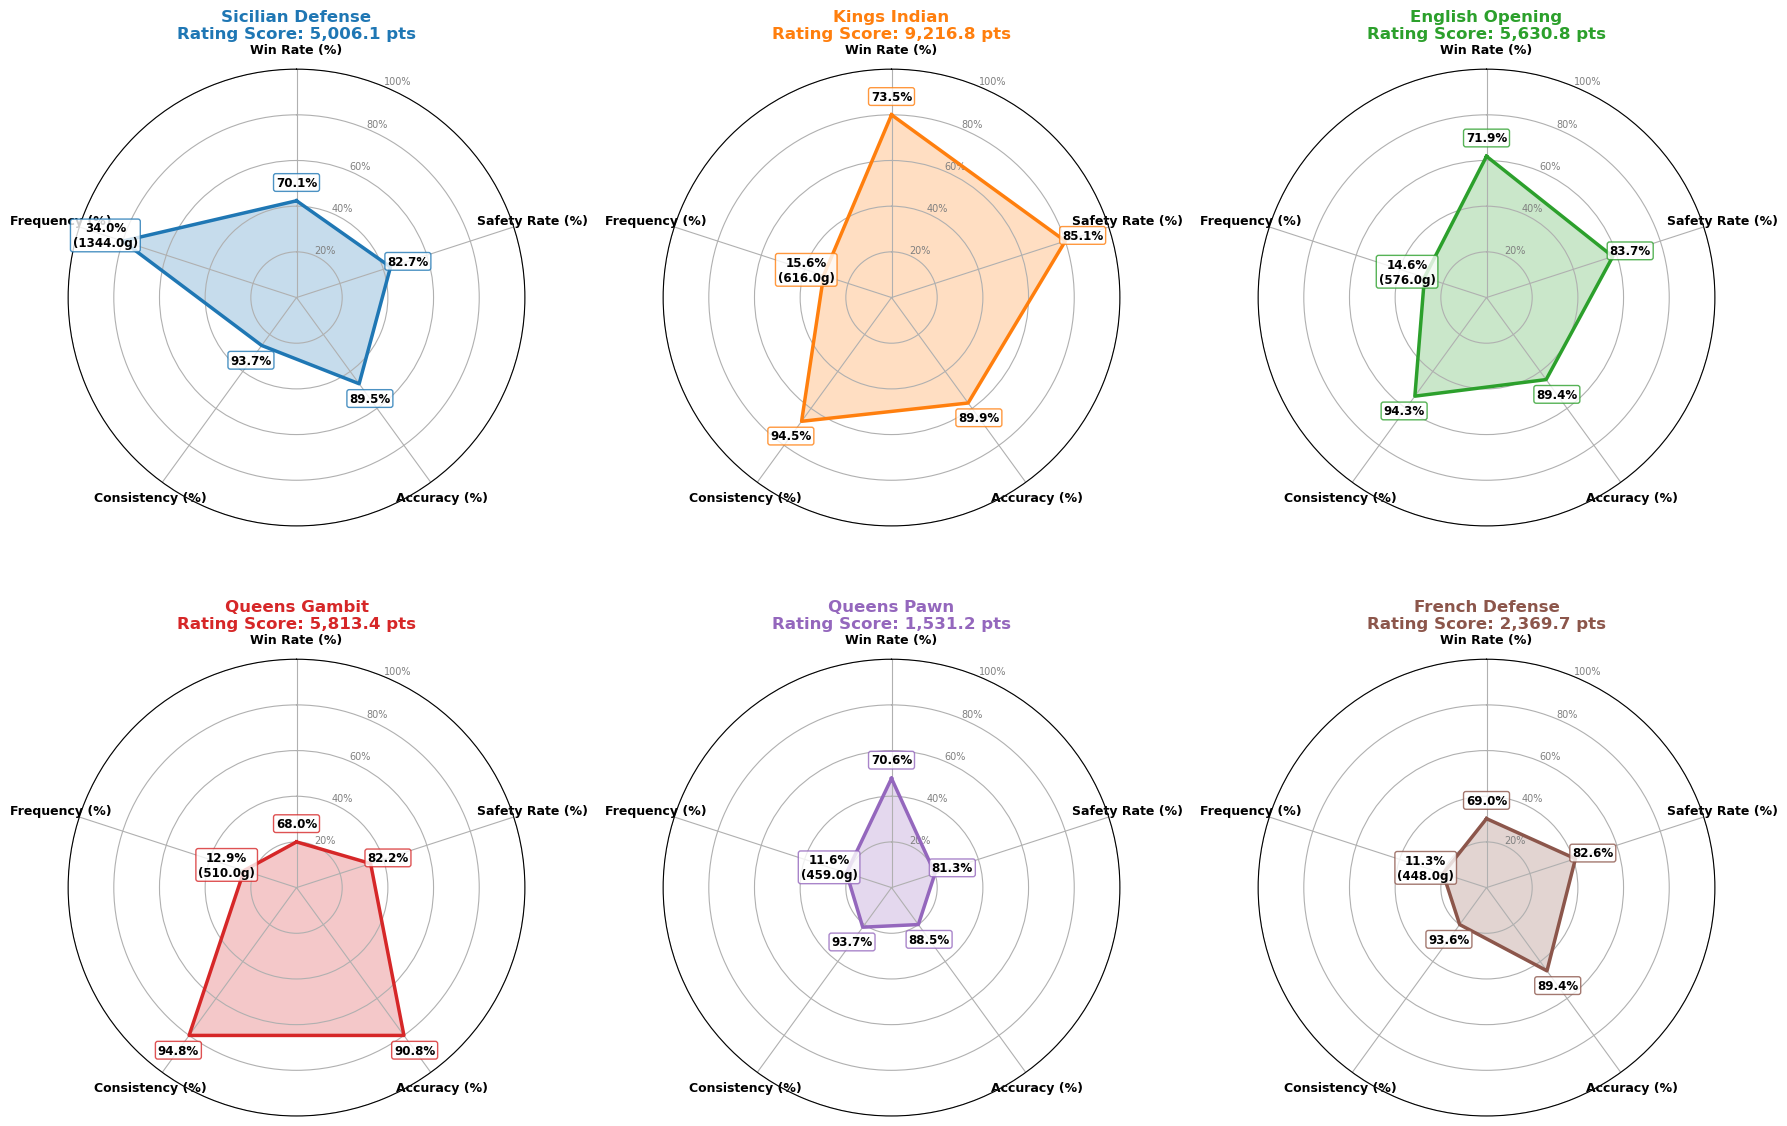

In [28]:
# Configure plot dimensions for 5-axis individual charts
num_vars = len(feature_cols)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles_closed = angles + angles[:1]  # Close radial loop

fig, axes = plt.subplots(
    2, 3, figsize=(18, 12), subplot_kw=dict(polar=True)
)
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for idx, (opening, row) in enumerate(metrics.iterrows()):
    ax = axes[idx]

    # Radial values (closed loop)
    r_padded = norm_df.loc[opening, feature_cols].values.tolist()
    r_padded_closed = r_padded + r_padded[:1]

    # Configure orientation
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Plot polygon & fill
    ax.plot(
        angles_closed,
        r_padded_closed,
        color=colors[idx],
        linewidth=2.5,
        linestyle='solid',
    )
    ax.fill(angles_closed, r_padded_closed, color=colors[idx], alpha=0.25)

    # Axis Labels & Radial limits
    ax.set_xticks(angles)
    ax.set_xticklabels(feature_cols, fontsize=9, weight='bold')
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=7, color='gray')

    # Annotate vertices with actual raw unit values
    raw_vals = row[feature_cols]
    for angle, r_val, col_name in zip(angles, r_padded, feature_cols):
        val = raw_vals[col_name]
        label_text = f"{val:.1f}%" if col_name != "Frequency (%)" else f"{val:.1f}%\n({row['total_games']}g)"
        
        # Slight radial offset for clarity
        ax.text(
            angle,
            r_val + 8,
            label_text,
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=8.5,
            weight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=colors[idx], alpha=0.8),
        )

    # Chart Sub-label / Title with Area Rating
    rating = row['area_rating']
    ax.set_title(
        f"{opening}\nRating Score: {rating:,.1f} pts",
        size=12,
        weight='bold',
        pad=22,
        color=colors[idx],
    )

plt.tight_layout()
plt.show()

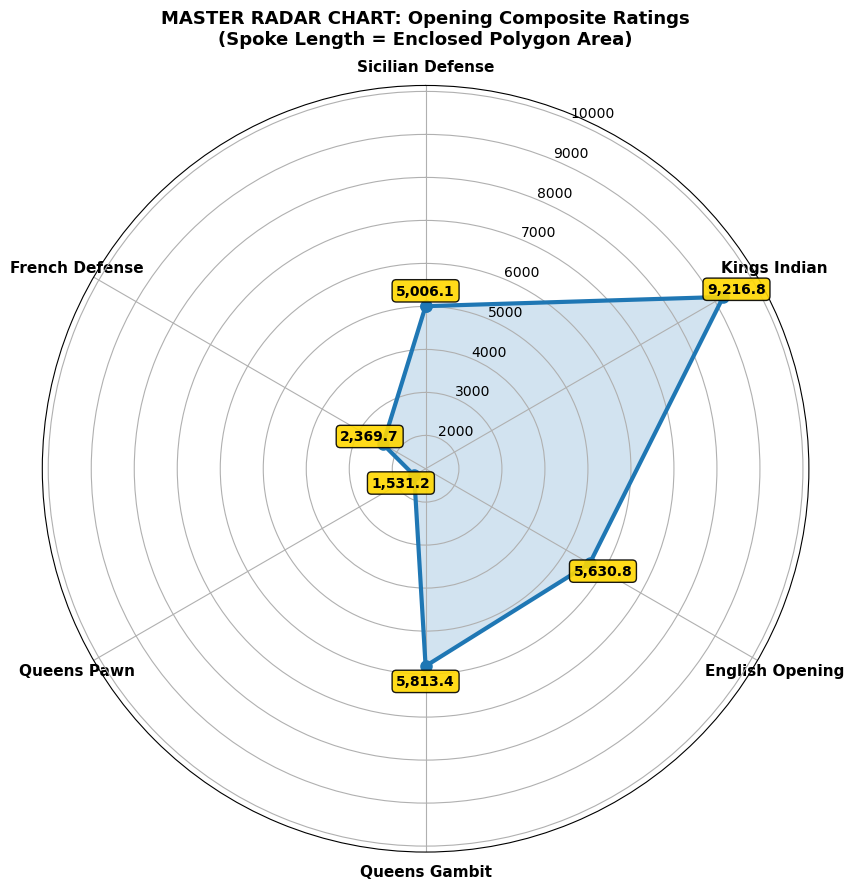

In [29]:
# Configure 6-axis Master Chart for comparing opening ratings
num_openings = len(metrics)
master_angles = np.linspace(0, 2 * np.pi, num_openings, endpoint=False).tolist()
master_angles_closed = master_angles + master_angles[:1]

ratings = metrics['area_rating'].values.tolist()
ratings_closed = ratings + ratings[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

# Configure orientation
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Plot Master Rating Polygon
ax.plot(
    master_angles_closed,
    ratings_closed,
    color='#1f77b4',
    linewidth=3,
    linestyle='-',
    marker='o',
    markersize=8,
)
ax.fill(master_angles_closed, ratings_closed, color='#1f77b4', alpha=0.2)

# Set Openings as Spokes
ax.set_xticks(master_angles)
ax.set_xticklabels(metrics.index, fontsize=11, weight='bold')

# Custom Padding bounds for Chart 7
min_rating = metrics['area_rating'].min()
max_rating = metrics['area_rating'].max()
lower_limit = min_rating * 0.80
upper_limit = max_rating * 1.10

ax.set_ylim(lower_limit, upper_limit)

# Annotate Area Ratings on Master Vertices
for angle, r_val, opening in zip(master_angles, ratings, metrics.index):
    ax.text(
        angle,
        r_val + (upper_limit - lower_limit) * 0.04,
        f'{r_val:,.1f}',
        horizontalalignment='center',
        verticalalignment='center',
        fontsize=10,
        weight='bold',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='gold',
            edgecolor='black',
            alpha=0.9,
        ),
    )

plt.title(
    'MASTER RADAR CHART: Opening Composite Ratings\n(Spoke Length = Enclosed Polygon Area)',
    fontsize=13,
    weight='bold',
    pad=30,
)
plt.tight_layout()
plt.show()